#Study 3: CO₂ per GDP (Carbon Intensity)

Which countries have the highest CO₂ emissions relative to their economic output?

### Objective:

Identify which countries emit the most CO₂ per dollar of GDP, to evaluate how carbon-intensive their economies are.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from modules.data_loader import DataLoader

## Load Preprocessed Data
We load 4 databases and merge into a single DataFrame with the following columns:
 `Continent`, `Country`, `year`, `co2`, `gdp`, `population`, `total_co2`, `total_gdp`

In [ ]:
# Load the preprocessed CSV 
loader = DataLoader()            # Create an instance of the DataLoader class
data = loader.load_and_prepare_data()  # Call the method to load and clean the data
data.head()

,Continent,Country,year,co2,gdp,population,total_co2,total_gdp
0,Africa,Algeria,1800,0.0,763.0,2500000.0,0.0,1.907500e+09
1,Africa,Algeria,1801,0.0,764.0,2510000.0,0.0,1.917640e+09
2,Africa,Algeria,1802,0.0,765.0,2520000.0,0.0,1.927800e+09
3,Africa,Algeria,1803,0.0,766.0,2530000.0,0.0,1.937980e+09
4,Africa,Algeria,1804,0.0,767.0,2540000.0,0.0,1.948180e+09


## Scatter Plot: Population vs CO₂ per Capita (2020)
Visualizing the correlation between population and CO₂ emissions for the year 2020.

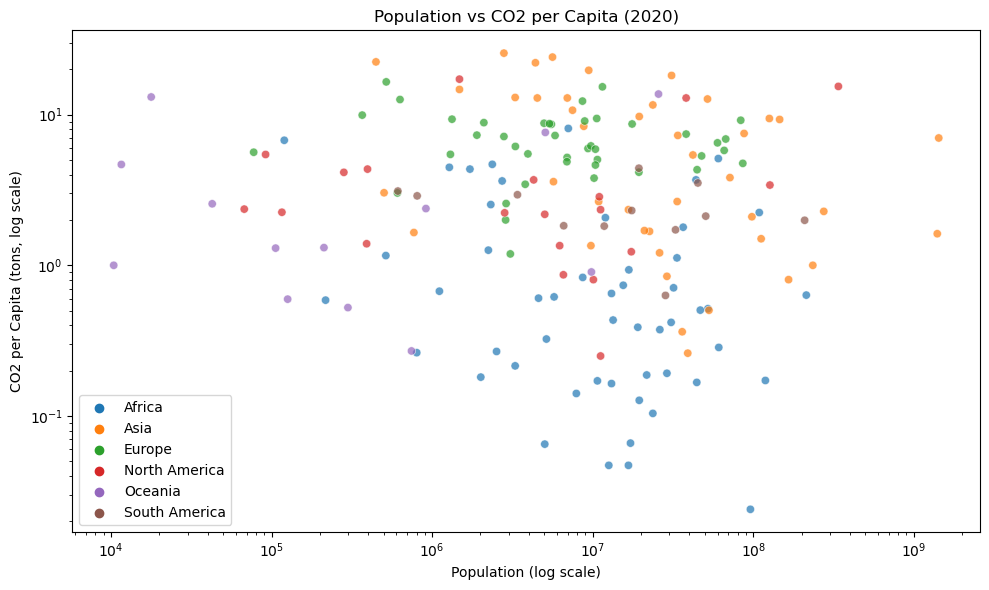

In [ ]:
# Define the year and number of countries to display
year_filter = 2020
top_n = 15
scatter_data = data[data["year"] == year_filter]

# Filter and prepare the data
df_year = data[data["year"] == year_filter].copy()

# Drop missing or invalid values
df_year = df_year.dropna(subset=["co2", "gdp"])
df_year = df_year.replace([np.inf, -np.inf], np.nan)
df_year = df_year.dropna(subset=["co2", "gdp"])

# Calculate carbon intensity: CO2 per unit of GDP
df_year["co2_per_gdp"] = df_year["co2"] / df_year["gdp"]

# Sort and select top N
top_countries = df_year.sort_values(by="co2_per_gdp", ascending=False).head(top_n)

# Plotting
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(top_countries["Country"], top_countries["co2_per_gdp"], color="crimson")

# Annotate values on bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', 
                xy=(bar.get_x() + bar.get_width() / 2, height), 
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

# Axis labeling
ax.set_title(f"Top {top_n} Countries by CO₂ per GDP (Carbon Intensity) - {year_of_interest}")
ax.set_ylabel("CO₂ per unit GDP (tons/USD)")
ax.set_xlabel("Country")
ax.set_xticklabels(top_countries["Country"], rotation=45, ha="right")

plt.tight_layout()
plt.show()



### Key Observations:
1. **No strong correlation** between population size and CO₂ per capita globally.
2. **Africa** mostly shows low population and very low CO₂ per capita (bottom-left).
3. **Asia** has a wide spread: India (low per capita), Qatar/UAE (high per capita).
4. **Europe/North America** cluster in high CO₂ per capita ranges.
5. **Outliers**:
   - High population & mid-high CO₂: USA, China
   - Low population & high CO₂: Qatar, UAE, Australia


